# Titanic - Attempt 1
- **Autor:** Felipe Silva Loschi
- **Data:** janeiro/2026 a abril/2026
- **Resultado:** 0.77511 acurácia
- **Abordagem:** Random Forest + Feature Engineering

> Notebook inicial de exploração do dataset do Titanic. Inclui análise exploratória, 
> justificativas de escalonamento e Feature Engineering que servirão de base para as tentativas seguintes.

Importando bibliotecas e funções necessárias

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

## Conhecendo os dados

### Importando e vendo

In [5]:
#df1 = pd.read_csv("data/gender_submission.csv")
df = pd.read_csv("../../data/train.csv")
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
282,283,0,3,"de Pelsmaeker, Mr. Alfons",male,16.0,0,0,345778,9.5000,NaN,S
612,613,1,3,"Murphy, Miss. Margaret Jane",female,NaN,1,0,367230,15.5000,NaN,Q
122,123,0,2,"Nasser, Mr. Nicholas",male,32.5,1,0,237736,30.0708,NaN,C
539,540,1,1,"Frolicher, Miss. Hedwig Margaritha",female,22.0,0,2,13568,49.5000,B39,C
157,158,0,3,"Corn, Mr. Harry",male,30.0,0,0,SOTON/OQ 392090,8.0500,NaN,S
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
512,513,1,1,"McGough, Mr. James Robert",male,36.0,0,0,PC 17473,26.2875,E25,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
701,702,1,1,"Silverthorne, Mr. Spencer Victor",male,35.0,0,0,PC 17475,26.2875,E24,S
81,82,1,3,"Sheerlinck, Mr. Jan Baptist",male,29.0,0,0,345779,9.5000,NaN,S


In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

### Sobre o dataset que eu pude entender no kaggle:
- PassengerID: ID do passageiro / NÃO INTERESSANTE
- Survived: Sobreviveu ou não / **IMPORTANTE**
- Pclass: A classe do passageiro(1[1° class], 2[2° class], 3[3° class]) / **IMPORTANTE**
- Name: Nome do passageiro / NÃO INTERESSANTE
- Sex: Sexo, vou ter que ajustar / **IMPORTANTE**
- Age: Idade, vou ter que categorizar / **IMPORTANTE**
- SibSp: Aparentemente é se a pessoa tem irmão ou esposa / *PODE SER INTERESSANTE, TALVEZ*
- Parch: Relações familiares / *PODE SER INTERESSANTE, TALVEZ*
- Ticket: Número da passagem / NÃO INTERESSANTE
- Fare: Aparentemente é o quanto a pessoa pagou para estar ali / **INTERESSANTE**
- Cabin: Número da cabine do passageiro, pode parecer desinteressante de começo, mas se parar pra pensar, o navio tombou pra um lado, se a pessoa estava do lado que estava tombando, a chance dela de escapar, teoricamente, é menor e vice-versa, então / **INTERESSANTE**
- Embarked: O lugar que a pessoa embarcou / NÃO SEI

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.shape

(891, 12)

### Sobre dados duplicados

In [9]:
df.duplicated().sum()

np.int64(0)

Não temos dados duplicados

In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Entendendo como funciona a coluna Parch

In [11]:
df["Parch"].sort_values(ascending=False)

678    6
610    5
638    5
13     5
885    5
      ..
20     0
21     0
22     0
23     0
6      0
Name: Parch, Length: 891, dtype: int64

### Outliers

In [12]:
num_cols = df.select_dtypes(include="number").columns

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

porcentagem_outliers = df[
    (df[num_cols] < lim_inf) |
    (df[num_cols] > lim_sup)
]

porcentagem_outliers.count()/len(df) * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age             1.234568
SibSp           5.162738
Parch          23.905724
Ticket          0.000000
Fare           13.019080
Cabin           0.000000
Embarked        0.000000
dtype: float64

Acima vemos a porcentagem de valores de cada coluna que é considerado um outlier(abaixo do limite inferior e acima do limite superior), que nos mostra algumas informações sobre o dataset, que tanto podem ser tratadas quanto não, dependendo se são ou não dados validos e importam para a análise

In [13]:
porcentagem_outliers.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,0.0,0.0,0.0,11.000000,46.000000,213.000000,116.000000
mean,NaN,NaN,NaN,69.772727,4.369565,1.596244,128.291629
std,NaN,NaN,NaN,4.568171,1.678077,0.882954,84.636908
min,NaN,NaN,NaN,65.000000,3.000000,1.000000,66.600000
25%,NaN,NaN,NaN,65.500000,3.000000,1.000000,78.189600
50%,NaN,NaN,NaN,70.000000,4.000000,1.000000,90.000000
75%,NaN,NaN,NaN,71.000000,4.750000,2.000000,147.778100
max,NaN,NaN,NaN,80.000000,8.000000,6.000000,512.329200


Como podemos ver pela média dos outliers, não possuímos nenhum outlier que seja um real erro de digitação ou algo do tipo, são apenas valores que são diferentes de seus pares, mas dentro da realidade. Logo, não há necessidade de tratá-los, já que são coisas que realmente podem acontecer.

In [14]:
df['Age'].sort_values(ascending=False)[:10]

630    80.0
851    74.0
493    71.0
96     71.0
116    70.5
745    70.0
672    70.0
33     66.0
456    65.0
54     65.0
Name: Age, dtype: float64

### Valores nulos

In [15]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Percebemos alguns valores nulos em algumas colunas, vamos ter que trata-los

In [16]:
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Cabin"].fillna("Unknown", inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


C:\Users\lipe2\AppData\Local\Temp\ipykernel_17024\1741642350.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
C:\Users\lipe2\AppData\Local\Temp\ipykernel_17024\1741642350.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

Como foi preenchido:
- Idade: Valor numérico que pode ser preenchido pela mediana, valor que vai ser menos afetado pelos outliers
- Cabin: Valor não numérico, que possui um conjunto de letra(andar) e número(quarto), então vou preenche-los com "Unknown", que faz mais sentido do que colocar várias pessoas em um único quarto, caso fosse substituido por algum valor específico.
- Embarked: Valor não numérico, mas que não é definido por conjunto letra-número, apenas letras, então podemos preenche-lo com a moda dos valores.

## Insights sobre o dataset

###Histograma da coluna Fare

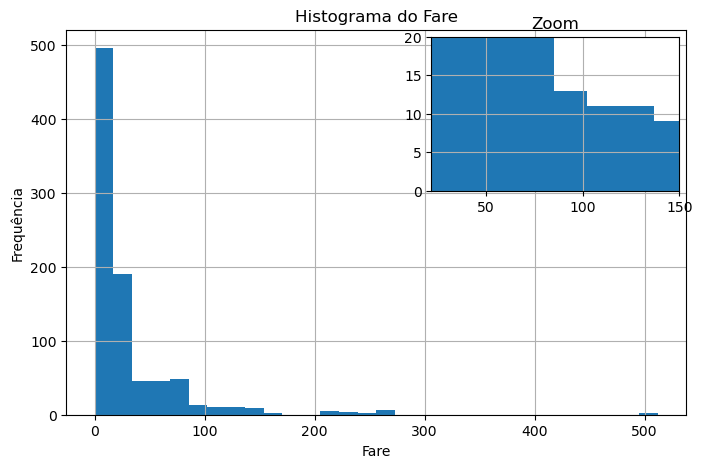

In [17]:
# Figura principal
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df['Fare'], bins=30)
ax.set_xlabel('Fare')
ax.set_ylabel('Frequência')
ax.set_title('Histograma do Fare')
ax.grid(True)

# --- INSET (zoom) ---
ax_inset = inset_axes(
    ax,
    width="40%",   # largura do inset
    height="40%",  # altura do inset
    loc="upper right"
)

# Intervalo menor
ax_inset.hist(
    df['Fare'],
    bins=30
)

ax_inset.set_xlim(22, 150)
ax_inset.set_ylim(0, 20)
ax_inset.set_title('Zoom')
ax_inset.grid(True)

plt.show()


Vendo pelo histograma, temos uma quantidade de passageiros que pagaram pouco pela passagem, mas não zero, o que é possível, uma vez que os valores das passagens do titanic eram variados.

### Matriz de correlação

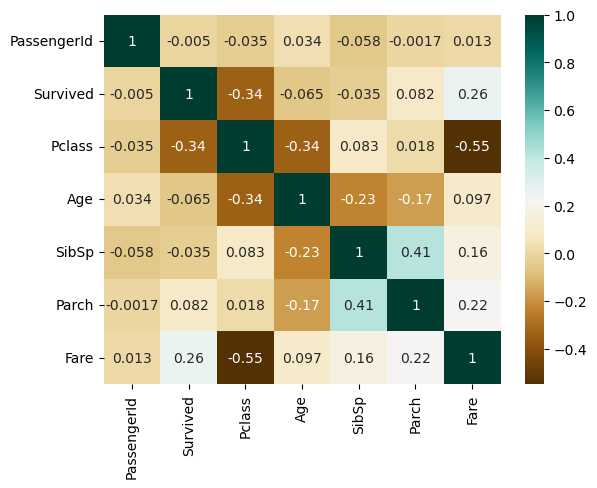

In [18]:
corr = df.corr(method="pearson", numeric_only=True)
plt.figure()
sns.heatmap(corr, cmap="BrBG", annot=True)
plt.show()

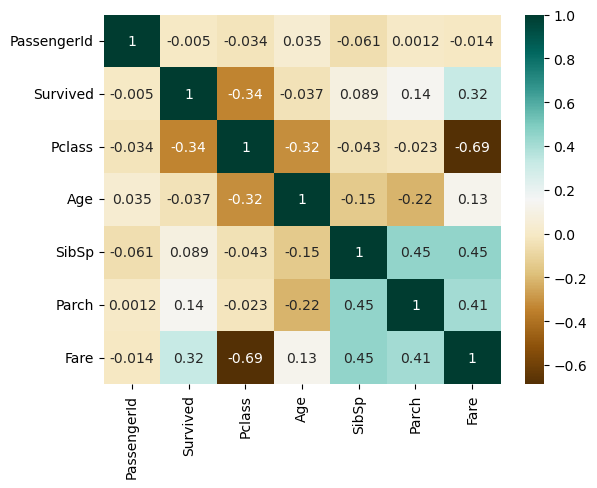

In [19]:
corr = df.corr(method="spearman", numeric_only=True)
plt.figure()
sns.heatmap(corr, cmap="BrBG", annot=True)
plt.show()

Levando em conta ambos os gráficos criados, com o coeficiente de spearman e pearson, vemos que as variáveis no geral possuem uma correlação fraca, sendo que algumas possuem uma correlação moderada, mas nenhuma possui uma correlação forte.

### KDE por idade e sobrevivência

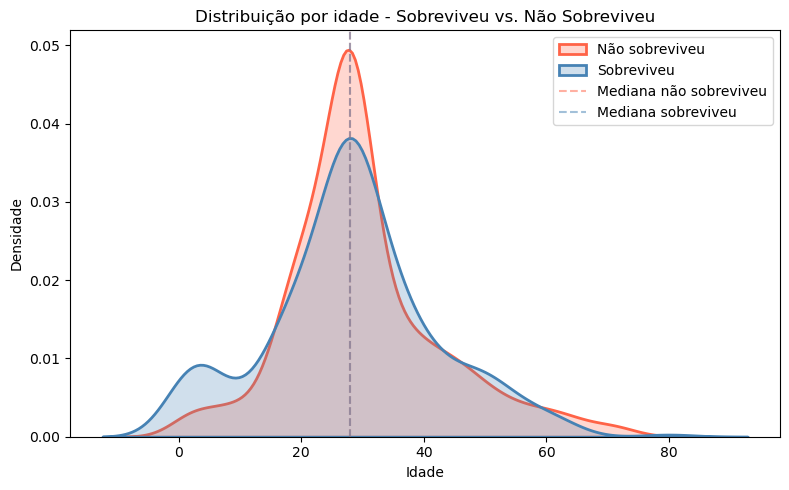

In [20]:
dados = np.random.normal(loc=50, scale=10, size=300)

fig, ax = plt.subplots(figsize=(8, 5))

sns.kdeplot(df[df['Survived']==0]['Age'], label = 'Não sobreviveu', fill=True, color='tomato', alpha=0.25, linewidth=2)
sns.kdeplot(df[df['Survived']==1]['Age'], label = 'Sobreviveu', fill=True, color='steelblue', alpha=0.25, linewidth=2)

ax.axvline(df[df['Survived'] == 0]['Age'].median(), label='Mediana não sobreviveu', color='tomato', linestyle='--', alpha=0.5)
ax.axvline(df[df['Survived'] == 1]['Age'].median(), label='Mediana sobreviveu', color='steelblue', linestyle='--', alpha=0.5)
ax.set_title('Distribuição por idade - Sobreviveu vs. Não Sobreviveu')
ax.set_xlabel('Idade')
ax.set_ylabel('Densidade')

plt.legend()
plt.tight_layout()
plt.show()

Olhando pelo gráfico, percebemos que para as menores idades, a taxa de sobrevivência foi maior que a de morte, o que faz sentido pensando no racícionio de que crianças e mulheres normalmente tem prioridade. Além disso, podemos ver que a mediana da idade de sobreviventes e de não sobreviventes é tão parecida que ambas as linhas se sobrepõe.

### Gráfico de barras de Survived por Pclass

Text(0, 0.5, 'Survived')

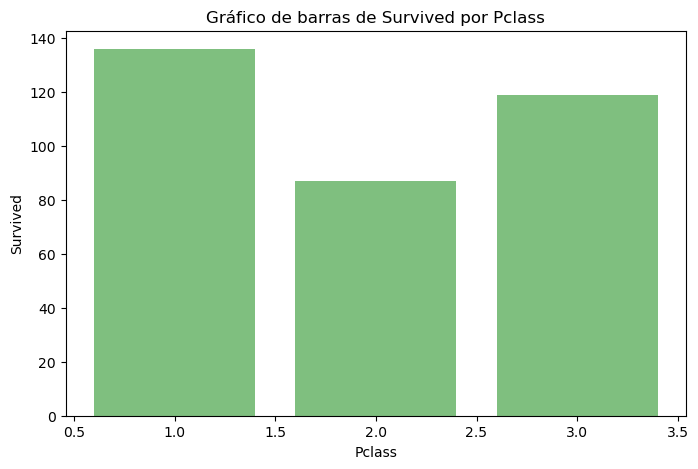

In [21]:
sobreviventes = df.groupby('Pclass')['Survived'].sum()

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(sobreviventes.index, sobreviventes, color = 'green', fill=True, alpha=0.5,)

ax.set_title("Gráfico de barras de Survived por Pclass")
ax.set_xlabel('Pclass')
ax.set_ylabel('Survived')

### Heatmap de Pclass: Sex x Taxa de sobrevivência

<Axes: xlabel='Sex', ylabel='Pclass'>

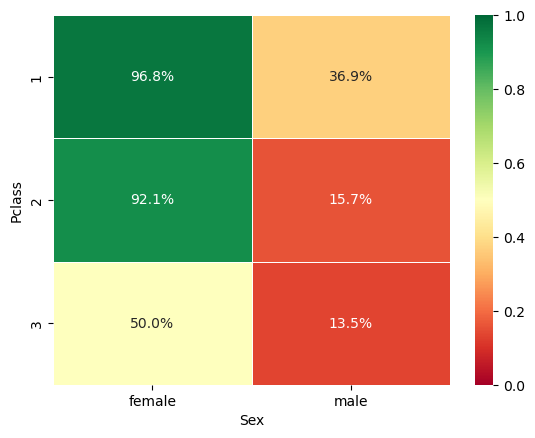

In [22]:
taxaDeSobrevivencia = df.groupby(['Pclass','Sex'])['Survived'].mean()
taxaDeSobrevivencia = taxaDeSobrevivencia.unstack()
sns.heatmap(taxaDeSobrevivencia,
            annot=True,        # mostra os valores dentro das células
            fmt='.1%',         # formata como percentual
            cmap='RdYlGn',     # paleta de cores (vermelho → amarelo → verde)
            vmin=0, vmax=1,    # escala de 0 a 100%
            linewidths=0.5,    # borda entre células
            )

Com esse Heatmap, conseguimos extrair a informação muito interessante de que se você fosse mulher, sua chance de sobreviver era maior, tanto que a taxa de sobrevivência de mulheres da 3ª classe é ainda maior que a de homens da 1ª. "Mulheres e crianças primeiro" foi levado muito a sério.

### Boxplot de Fare por Pclass

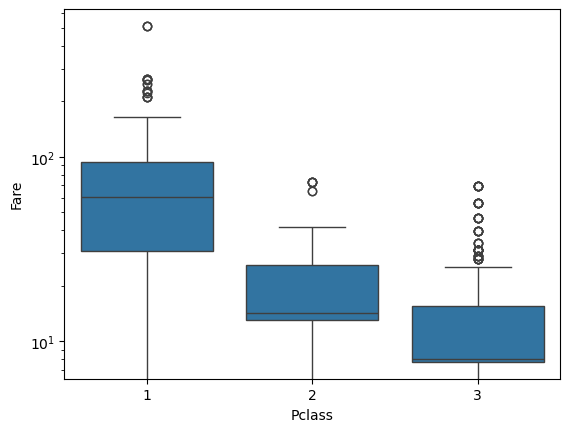

In [23]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='Pclass', y='Fare', ax=ax)
ax.set_yscale('log')

Com esse boxplot, conseguimos tirar algumas informações interessantes sobre o quanto foi pago por cada classe. Para a 1ª classe, conseguimos ver que sua mediana está por volta dos 50, sendo considerado um outlier em outras classes, além de que a mesma possui um grande número de outliers, possuindo um em específico que é maior que os outros, estando na casa dos 500. Para a 2ª classe, ela possui uma mediana próximo de 15 e apenas dois outliers, mostrando que os preços dessa classe eram bem homgêneos. Já na 3ª classe, possuímos uma mediana abaixo de 10 e um grande número de outliers, tendo alguns que pagaram até mais que os valores pagos pela 2ª classe. Interessante de ser evidenciado é que a diferença entre a 1ª classe e a 2ª é bem maior que a diferença entre a 2ª e a 3ª.

### Pairplot com hue='Survived'

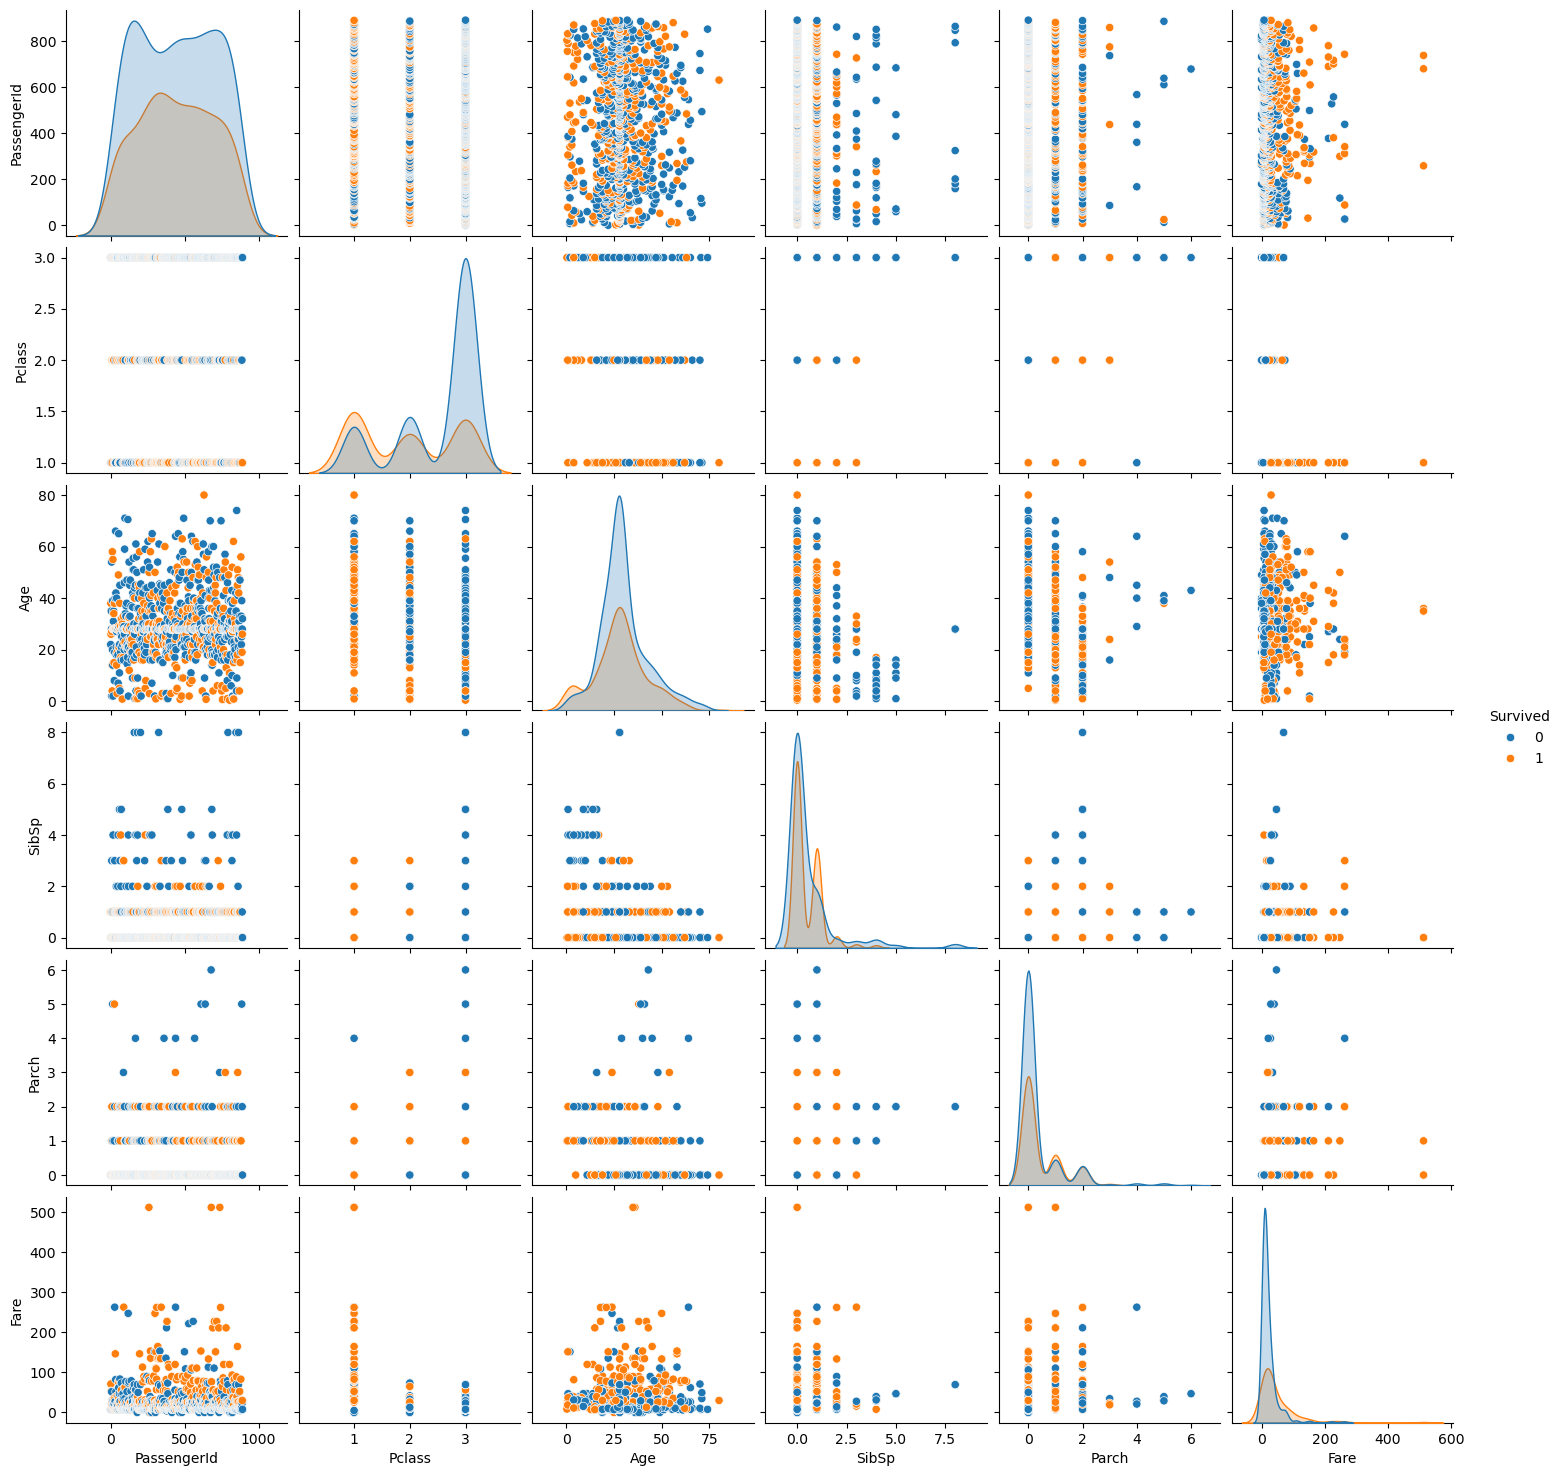

In [24]:
sns.pairplot(data=df, hue='Survived')

#### Fare x Age:
Conseguimos ver que quem pagou mais, em sua maioria, conseguiu sobreviver, reforçado pelos outliers que pagaram acima de 200, o que mostra que pagar mais é um fator importante para sobrevivência e alguns dos que pagaram menos, mas são mais novos também conseguiram. Dos que são mais velhos e pagaram menos, mas sobreviveram, por analises anteriores, são mulheres em sua maioria.

#### Pclass X Age:
Conseguimos ver que na 1ª classe a sua grande maioria sobreviveu. Na 2ª classe, uma parte dos mais novos e alguns mais velhos, provavelmente mulheres em sua maioria, também sobreviveram. Na 3ª classe, a grande maioria não sobreviveu, sendo que aqueles que sobreviveram são em sua maioria mais novos.

#### Pclass X Fare:
Confirma analises anteriores.

### Taxa de Sobrevivência por Embarked

<Axes: xlabel='Embarked', ylabel='Survived'>

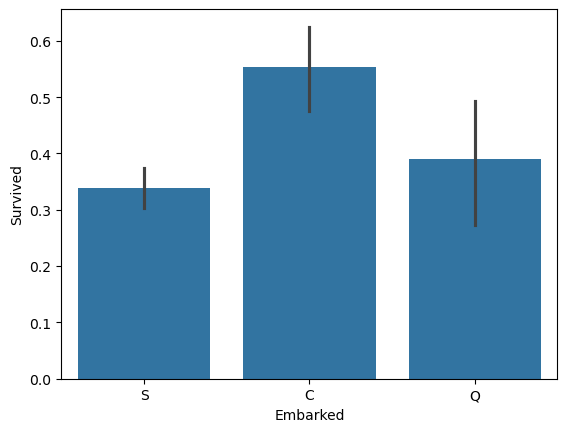

In [25]:
sns.barplot(data = df, x = 'Embarked', y = 'Survived')

Por esse plot, conseguimos notar algo interessante, por mais que o porto onde a pessoa embarcou pareça intuitivamente não influenciar na taxa de sobrevivência, pelo gráfico, vemos que quem embarcou no porto C possui uma taxa maior de sobrevivência que quem embarcou nos outros portos. Essa correlação pode ser uma correlação espúria, visto que a maior parte das pessoas que embarcaram no porto C(Cherbourg) são, em sua maioria, da 1ª classe, o que explica a taxa de sobrevivência maior, não necessariamente o porto em si.

### Taxa de sobrevivência por SibSp e Parch

<Axes: xlabel='Parch', ylabel='SibSp'>

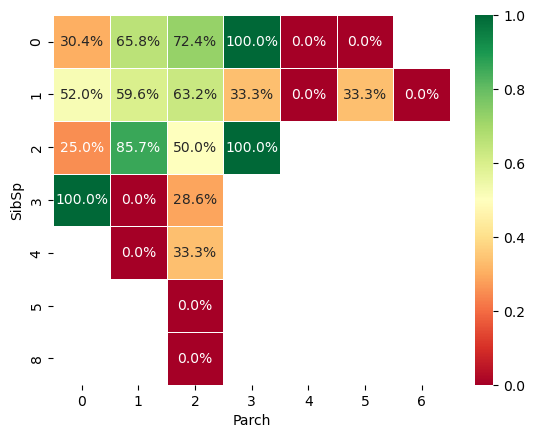

In [26]:
taxaDeSobrevivencia = df.groupby(['SibSp','Parch'])['Survived'].mean()
taxaDeSobrevivencia = taxaDeSobrevivencia.unstack()
sns.heatmap(taxaDeSobrevivencia,
            annot=True,        # mostra os valores dentro das células
            fmt='.1%',         # formata como percentual
            cmap='RdYlGn',     # paleta de cores (vermelho → amarelo → verde)
            vmin=0, vmax=1,    # escala de 0 a 100%
            linewidths=0.5,    # borda entre células
            )

Pelo heatmap, pessoas que possuiam um grande número de relações familiares(mais de 5) tiveram menores chances de sobreviver, o que faz sentido, visto que é mais díficil de coordenar a sobrevivência de um grupo maior em vista de um menor.

### Títulos extraídos do nome

In [27]:
# Olhando para os nomes das pessoas no DataFrame, eles estão no estilo
#Braund, Mr. Owen Harris, o que significa que o título está entre a
#vírgula e o ponto.
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.') #Esse é o Regex que extrai isso em Python
df['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

Procurando um pouco, descubro que:
- Mr — homens adultos em geral
- Miss — mulheres solteiras
- Mrs — mulheres casadas
- Master — meninos jovens (geralmente abaixo de 15 anos)
- Dr — médicos
- Rev — reverendos/padres
- Col / Major / Capt — militares
- Mlle — equivalente francês de Miss
- Mme — equivalente francês de Mrs
- Ms — mulher sem distinção de estado civil
- Don — título nobre espanhol
- Lady / Sir / the Countess / Jonkheer — títulos de nobreza europeia

Antes de plotar a taxa de sobrevivencia por título, vamos agrupar os títulos raros e títulos que possuem o mesmo significado em línguas diferentes.

In [28]:
df['Title'] = df['Title'].replace({
    'Mlle':'Miss',
    'Mme':'Mrs',
    'Col':'Rare',
    'Major':'Rare',
    'Capt':'Rare',
    'Rev':'Rare',
    'Don': 'Rare',
    'Lady':'Rare',
    'Sir':'Rare',
    'the Countess':'Rare',
    'Jonkheer':'Rare'
})

<Axes: xlabel='Title', ylabel='Survived'>

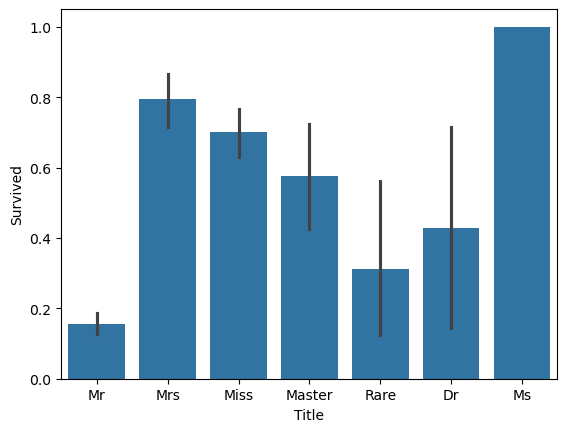

In [29]:
sns.barplot(data = df, x = 'Title', y = 'Survived')

Com o gráfico, percebemos o que haviamos analisado antes, mulheres e crianças sobreviveram mais do que homens. Já para os títulos raros, como foi agrupado títulos com perfis diferentes(militares, nobres, religiosos), essa diferença pode ter causado uma queda na taxa de sobrevivência, visto que alguns desses podem ter priorizado ajudar mulheres e crianças a sobreviverem.

## Machine Learning:

Colunas que vou usar:
- PassangerId: não
- Name: não
- Ticket: não
- Cabin: por mais que fosse interessante, temos muitos valores nulos, não vale a penas
- Pclass: sim
- Sex: sim
- Age: sim
- SibSp: sim
- Parch: sim
- Fare: sim
- Embarked: sim
- Title: sim

### Escalonamento para numéricos
- Normalização: Por mais que pudesse ser, a decisão de não tratar os outliers torna isso aqui inviável, já que ele é sensível a outliers
- Padronização: Pode ser, ele é robusto a outliers e não temos outliers muito extremos
- Escalonamento Robusto: Mínima influência de outliers, mas mais interessante para outliers extremos.

**Resultado**: Padronização

### Escalonamento para não-numéricas
- One-Hot Enconding: Nominais e baixa cardinalidade, mas pode gerar uma alta dimensionalidade
- Label Encoding: Codificação do rótulo em problema de classificação. Pode introduzir relação de ordem falsa que afeta negativa algoritmos sensíveis a distâncias ou magnitude.
- Target Encoding: Substitui cada categoria pela média do valor do alvo. Interessante para alta cardinalidade.
- Binary Encoding: Combina One-Hot e Label. Cada valor recebe um valor inteiro que depois é convertido para binário. Ótimo para alta cardinalidade

**Resultado**: Devido a baixa cardinalidade de todas as variáveis não numéricas, opto por One-Hot Encoding

Sobre as variáveis que irei escalonar:
- **Padronização**: Age, SibSp, Parch e Fare
- **One-Hot**: Sex, Embarked, Title
* **Sem transformações**: Pclass, pois é uma variável numérica discreta e vou usar algoritmo baseado em árvore

In [30]:
numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Sex', 'Embarked', 'Title']

In [31]:
# O ColumnTransformer aplica transformações por coluna especificada.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop='first'), categorical_features)
    ]
)

In [32]:
#Dividindo em Features e Target
X = df.drop('Survived', axis=1)
y = df['Survived']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
X_train

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
331,332,1,"Partner, Mr. Austen",male,45.5,0,0,113043,28.5000,C124,S,Mr
733,734,2,"Berriman, Mr. William John",male,23.0,0,0,28425,13.0000,Unknown,S,Mr
382,383,3,"Tikkanen, Mr. Juho",male,32.0,0,0,STON/O 2. 3101293,7.9250,Unknown,S,Mr
704,705,3,"Hansen, Mr. Henrik Juul",male,26.0,1,0,350025,7.8542,Unknown,S,Mr
813,814,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,347082,31.2750,Unknown,S,Miss
...,...,...,...,...,...,...,...,...,...,...,...,...
106,107,3,"Salkjelsvik, Miss. Anna Kristine",female,21.0,0,0,343120,7.6500,Unknown,S,Miss
270,271,1,"Cairns, Mr. Alexander",male,28.0,0,0,113798,31.0000,Unknown,S,Mr
860,861,3,"Hansen, Mr. Claus Peter",male,41.0,2,0,350026,14.1083,Unknown,S,Mr
435,436,1,"Carter, Miss. Lucile Polk",female,14.0,1,2,113760,120.0000,B96 B98,S,Miss


In [35]:
pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(max_depth = 5,
                                     min_samples_leaf = 4,
                                     n_estimators=100))
])

Treinando o modelo

In [36]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Sex', 'Embarked',
                                                   'Title'])])),
                ('model',
                 RandomForestClassifier(max_depth=5, min_samples_leaf=4))])

Testando o modelo

In [37]:
y_train_predict = pipeline.predict(X_train)
print(f"Acurácia do modelo: {accuracy_score(y_train, y_train_predict):.2f}")

Acurácia do modelo: 0.83


In [38]:
y_test_predict = pipeline.predict(X_test)
print(f"Acurácia do modelo: {accuracy_score(y_test, y_test_predict):.2f}")

Acurácia do modelo: 0.82


Valor dos parâmetro do RandomForest foi decidido por tentativas.
Para max_depth:
- Para 4: Treino = 83%, Teste = 82%
- Para 5: Treino = 84%, Teste = 83%
- Para 6: Treino = 85%, Teste = 82%
- Para 7: Treino = 87%, Teste = 83%
- Para 8: Treino = 89%, Teste = 83%
- Para 9: Treino = 91%, Teste = 82%

Com isso, é possível notar o crescente overfitting, optando, então por max_depth = 5, onde tem o melhor resultado.

Para min_samples_leaf com max_depth = 5:
- Para 2: Treino = 84%, Teste = 82%
- Para 4: Treino = 83%, Teste = 82%
- Para 6: Treino = 83%, Teste = 81%
- Para 8: Treino = 83%, Teste = 82%
- Para 10: Treino = 83%, Teste = 82%

Com isso, opto por min_samples_leaf = 4.

Para n_estimators com max_depth = 5 e min_sample_leafs = 4:
- Para 50: Treino = 84%, Teste = 82%
- Para 100: Treino = 83%, Teste = 83%
- Para 200: Treino = 84%, Teste = 82%
- Para 300: Treino = 83%, Teste = 82%

Com isso, opto por 100, onde chego ao melhor resultado possível.

### DataSet de Test

Primeiro vamos criar a coluna 'Title' que só existe no normal

In [39]:
df_test = pd.read_csv('test.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'test.csv'

In [ ]:
df_test['Title'] = df_test['Name'].str.extract(r',\s*([^\.]+)\.') #Esse é o Regex que extrai isso em Python
df_test['Title'] = df_test['Title'].replace({
    'Mlle':'Miss',
    'Mme':'Mrs',
    'Col':'Rare',
    'Major':'Rare',
    'Capt':'Rare',
    'Rev':'Rare',
    'Don': 'Rare',
    'Lady':'Rare',
    'Sir':'Rare',
    'the Countess':'Rare',
    'Jonkheer':'Rare',
    'Dona':'Rare'
})

In [ ]:
df_resposta = pd.DataFrame({'PassengerId' : df_test['PassengerId'],
                           'Survived' : pipeline.predict(df_test)})

In [ ]:
df_resposta.to_csv('Resposta.csv', index=False)